I think here it would be nice to just try a logistic regression with the same features as the random forest, and see how it performs. 

if it performs similarly, then we can say that the random forest is not really capturing any complex relationships, and that a simpler model can do just as well. if it performs much worse, then we can say that the random forest is capturing some non-linear relationships that the logistic regression cannot capture.

here just testing if there was an impact on that cell or not?

In [119]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'Helvetica'
%matplotlib inline

# read in our data
X_train = pd.read_csv('../data/cleaned_model_data/complex_filling/final/x_train.csv', index_col=0)
X_test = pd.read_csv('../data/cleaned_model_data/complex_filling/final/x_test.csv', index_col=0)
y_train = pd.read_csv('../data/cleaned_model_data/complex_filling/final/y_train.csv', index_col=0)
y_test = pd.read_csv('../data/cleaned_model_data/complex_filling/final/y_test.csv', index_col=0)

X_train.drop(columns=['grid_point_id'], inplace=True)
X_test.drop(columns=['grid_point_id'], inplace=True)

# #we need to make our target varaible from a % impact into a binary variable
y_train_new = (y_train['percent_houses_damaged'] > 0).astype(int)
y_test_new = (y_test['percent_houses_damaged'] > 0).astype(int)


model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced"))
model.fit(X_train, y_train_new)

y_pred = model.predict(X_test)

print(classification_report(y_test_new, y_pred, target_names=["Not Impacted", "Impacted"]))

              precision    recall  f1-score   support

Not Impacted       0.95      0.73      0.82      7187
    Impacted       0.26      0.70      0.38       963

    accuracy                           0.72      8150
   macro avg       0.60      0.72      0.60      8150
weighted avg       0.87      0.72      0.77      8150



In [99]:
# Returns "Impacted" / "Not Impacted" for each row
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]  # probability of being impacted

results = pd.DataFrame({
    "impacted":    predictions,
    "probability": probabilities.round(3),
    "actual": y_test_new.values
})
results["impacted"] = results["impacted"].map({1: "Impacted", 0: "Not Impacted"})

In [102]:
results.groupby("actual")["probability"].describe()

# actual
# 0    0.359
# 1    0.651

,count,mean,std,min,25%,50%,75%,max
actual,,,,,,,,
0,7187.0,0.390350,0.203135,0.0,0.2460,0.359,0.5085,0.999
1,963.0,0.601268,0.199447,0.0,0.4615,0.651,0.7550,0.976


In [103]:
#confusion matrix cmap
cm_cmap = mcolors.LinearSegmentedColormap.from_list(
    "confusion_cmap",
    ["#EDE8EB", "#87677B", "#68505F"],
    # N=5   # snap to exactly 4 discrete colors
)

#confusion matrix cmap
same_scale_color_map = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#D6F1FF', '#33BBFF', '#0088ce', '#005F8F', '#001B29']
)


#ADE4FF

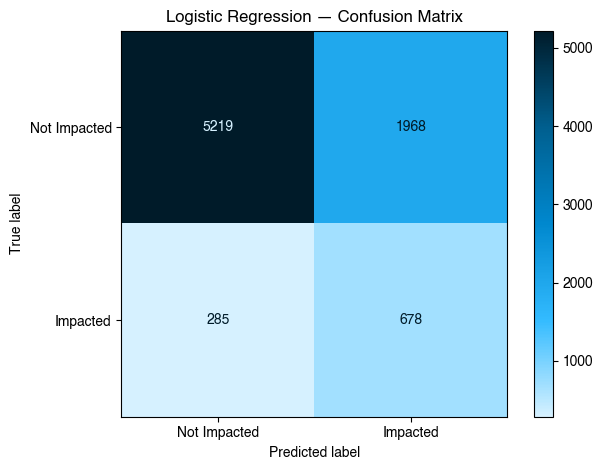

In [104]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_new, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"])
disp.plot(cmap=same_scale_color_map)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

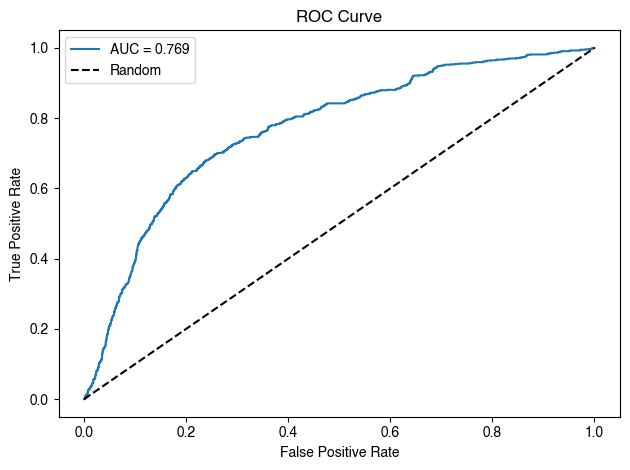

In [105]:
auc = roc_auc_score(y_test_new, probabilities)
fpr, tpr, _ = roc_curve(y_test_new, probabilities)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
param_grid = {
    "logisticregression__C":           [0.01, 0.1, 1, 10, 100],
    "logisticregression__penalty":     ["l1", "l2"],
    "logisticregression__solver":      ["liblinear", "saga"]
}

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced"))

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train_new)

print("Best AUC:   ", grid_search.best_score_.round(3))
print("Best params:", grid_search.best_params_)

# Best AUC:    0.771
# Best params: {'logisticregression__C': 1, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}

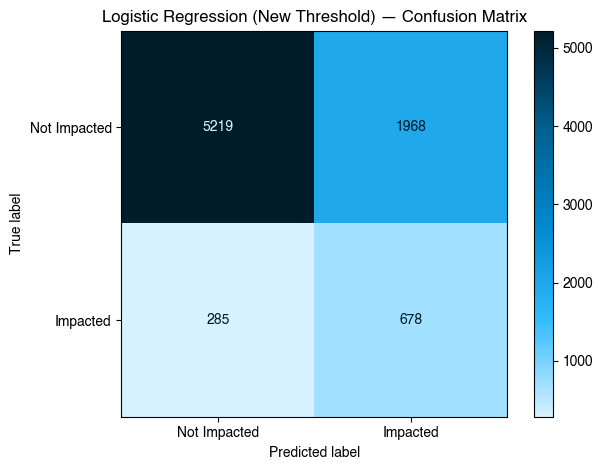

In [110]:
#keep the set up we had before, it seemed fine 
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced",C=1, l1_ratio=0, solver="liblinear"))
model.fit(X_train, y_train_new)

probabilities = model.predict_proba(X_test)[:, 1]  # probability of being impacted
# predictions_updated = (probabilities >= 0.669109).astype(int)
preds = model.predict(X_test)

cm = confusion_matrix(y_test_new, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"])
disp.plot(cmap=same_scale_color_map)
plt.title("Logistic Regression (New Threshold) — Confusion Matrix")
plt.tight_layout()
plt.show()

Try a bigger grid search to see if we can improve this model at all:

In [ ]:
param_grid = {
    "logisticregression__C":            [0.01, 0.1, 1, 10, 100],
    "logisticregression__penalty":      ["l1", "l2", "elasticnet"],
    "logisticregression__solver":       ["saga"],  # saga supports all penalties
    "logisticregression__l1_ratio":     [0.0, 0.25, 0.5, 0.75, 1.0],  # for elasticnet
    "logisticregression__class_weight": ["balanced", {0: 1, 1: 2}, {0: 1, 1: 3}],
}

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced"))

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train_new)

print("Best AUC:   ", grid_search.best_score_.round(3))
print("Best params:", grid_search.best_params_)

# 76 min to run
# Best AUC:    0.769
# Best params: {'logisticregression__C': 10, 'logisticregression__class_weight': 'balanced', 'logisticregression__l1_ratio': 1.0, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'saga'}

Try some different thresholds to determine the best F1 cut off:

In [113]:
from sklearn.metrics import f1_score

best_thresh, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.01):
    preds_t = (probabilities >= t).astype(int)
    f1 = f1_score(y_test_new, preds_t)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"Best threshold: {best_thresh:.2f} | Best F1: {best_f1:.3f}")

Best threshold: 0.58 | Best F1: 0.409


Trying the gridsearch with a differnt scoring metric to see if it helps at all:

In [ ]:
#redo grid search with different scoring: 
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring="f1",   # optimise directly for what you care about
    n_jobs=-1,
)

grid_search.fit(X_train, y_train_new)

print("Best AUC:   ", grid_search.best_score_.round(3))
print("Best params:", grid_search.best_params_)
best_model_f1 = grid_search.best_estimator_
predictions = best_model_f1.predict(X_test)
f1 = f1_score(y_test_new, predictions)
print(f'Best f1: {f1}')

# Best AUC:    0.37
# Best params: {'logisticregression__C': 0.1, 'logisticregression__class_weight': 'balanced', 'logisticregression__l1_ratio': 0.5, 'logisticregression__penalty': 'elasticnet', 'logisticregression__solver': 'saga'}
# Best f1: 0.3885877318116976

Best f1: 0.3885877318116976


/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/elena/Documents/python_projects/ntl_thesis_gecp_2026/ntlthesis/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


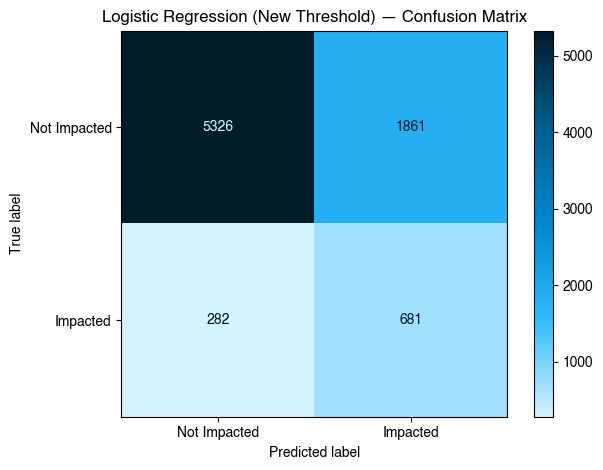

In [116]:
#keep the set up we had before, it seemed fine 
model = make_pipeline(StandardScaler(), best_model_f1)
model.fit(X_train, y_train_new)

probabilities = model.predict_proba(X_test)[:, 1]  # probability of being impacted
# predictions_updated = (probabilities >= 0.669109).astype(int)
preds = model.predict(X_test)

cm = confusion_matrix(y_test_new, preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"])
disp.plot(cmap=same_scale_color_map)
plt.title("Logistic Regression (New Threshold) — Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
#keep the set up we had before, it seemed fine 
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced",C=1, l1_ratio=0, solver="liblinear"))
model.fit(X_train, y_train_new)

# make copies of the dataframes to add predictions to
X_train_with_preds = X_train.copy()
X_test_with_preds = X_test.copy()

#add predictions to the dataframes
X_train_with_preds["impacted_pred"] = model.predict(X_train)
X_train_with_preds["impacted_prob"] = model.predict_proba(X_train)[:, 1].round(3)

X_test_with_preds["impacted_pred"] = model.predict(X_test)
X_test_with_preds["impacted_prob"] = model.predict_proba(X_test)[:, 1].round(3)

X_train_with_preds.to_csv('../data/cleaned_model_data/complex_filling/x_train_with_predictions.csv', index=True)
X_test_with_preds.to_csv('../data/cleaned_model_data/complex_filling/x_test_with_predictions.csv', index=True)
y_train.to_csv('../data/cleaned_model_data/complex_filling/y_train_2_preds.csv', index=True)
y_test.to_csv('../data/cleaned_model_data/complex_filling/y_test_2_preds.csv', index=True)

In [26]:
X_train_with_preds.index == y_train.index

array([ True,  True,  True, ...,  True,  True,  True], shape=(19015,))

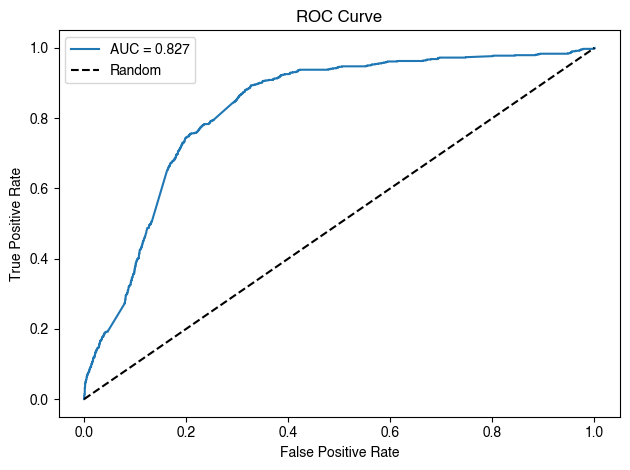

In [81]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced",C=1, l1_ratio=0, solver="liblinear"))
model.fit(X_train, y_train_new)

# Returns "Impacted" / "Not Impacted" for each row
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]  # probability of being impacted

auc = roc_auc_score(y_test_new, probabilities)
fpr, tpr, _ = roc_curve(y_test_new, probabilities)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [107]:
thresholds = [0.3, 0.4, 0.5, 0.6,0.601268, 0.651, 0.7]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'F1':<10}")
print("-" * 44)
for t in thresholds:
    preds_t = (probabilities >= t).astype(int)
    print(f"{t:<12} "
          f"{precision_score(y_test_new, preds_t):<12.3f}"
          f"{recall_score(y_test_new, preds_t):<10.3f}"
          f"{f1_score(y_test_new, preds_t):<10.3f}")

Threshold    Precision    Recall     F1        
--------------------------------------------
0.3          0.160       0.921     0.273     
0.4          0.203       0.805     0.324     
0.5          0.256       0.704     0.376     
0.6          0.314       0.570     0.405     
0.601268     0.315       0.569     0.405     
0.651        0.335       0.498     0.401     
0.7          0.343       0.329     0.336     


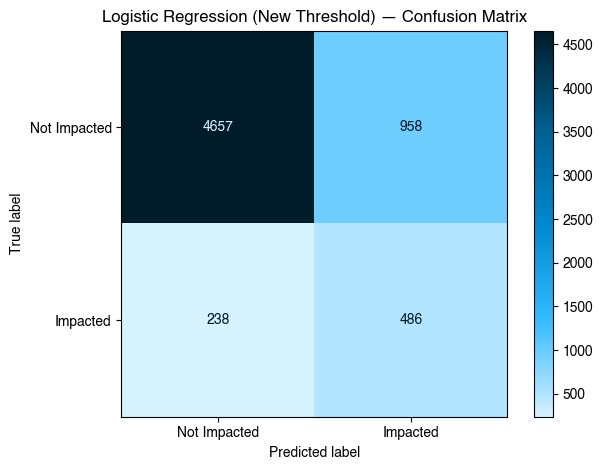

In [77]:
probabilities = model.predict_proba(X_test)[:, 1]  # probability of being impacted
predictions_updated = (probabilities >= 0.669109).astype(int)

cm = confusion_matrix(y_test_new, predictions_updated)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"])
disp.plot(cmap=same_scale_color_map)
plt.title("Logistic Regression (New Threshold) — Confusion Matrix")
plt.tight_layout()
plt.show()

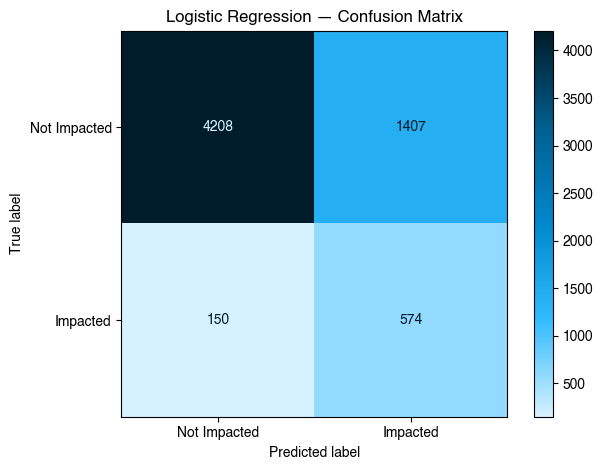

In [62]:
cm = confusion_matrix(y_test_new, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"])
disp.plot(cmap=same_scale_color_map)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

In [63]:
from sklearn.metrics import (f1_score, precision_score, recall_score, 
                             balanced_accuracy_score, matthews_corrcoef)

print(f"F1 (Impacted):       {f1_score(y_test_new, predictions):.3f}")
print(f"Precision (Impacted):{precision_score(y_test_new, predictions):.3f}")
print(f"Recall (Impacted):   {recall_score(y_test_new, predictions):.3f}")
print(f"Balanced Accuracy:   {balanced_accuracy_score(y_test_new, predictions):.3f}")
print(f"MCC:                 {matthews_corrcoef(y_test_new, predictions):.3f}")
print(f"AUC:                 {auc:.3f}")
print()
print(classification_report(y_test_new, predictions, target_names=["Not Impacted", "Impacted"]))

F1 (Impacted):       0.424
Precision (Impacted):0.290
Recall (Impacted):   0.793
Balanced Accuracy:   0.771
MCC:                 0.372
AUC:                 0.827

              precision    recall  f1-score   support

Not Impacted       0.97      0.75      0.84      5615
    Impacted       0.29      0.79      0.42       724

    accuracy                           0.75      6339
   macro avg       0.63      0.77      0.63      6339
weighted avg       0.89      0.75      0.80      6339



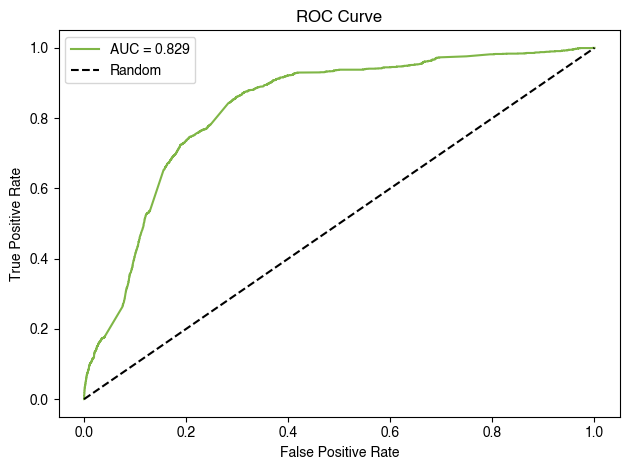

In [60]:
# Returns "Impacted" / "Not Impacted" for each row
predictions_train = model.predict(X_train)
probabilities_train = model.predict_proba(X_train)[:, 1]  # probability of being impacted

auc = roc_auc_score(y_train_new, probabilities_train)
fpr, tpr, _ = roc_curve(y_train_new, probabilities_train)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='#7FB646')
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

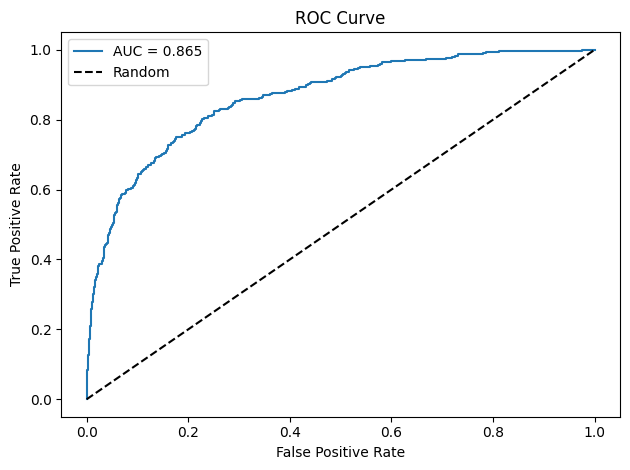

In [ ]:
# Quick check on how this compares if we filter out by data availability

# was the best 0.01
train_mask = X_train.perc_available_upscaled_new >= 0.1
test_mask = X_test.perc_available_upscaled_new >= 0.1

X_train_filt = X_train[train_mask]
y_train_new_filt = y_train_new[train_mask]

X_test_filt = X_test[test_mask]
y_test_new_filt = y_test_new[test_mask]

# Returns "Impacted" / "Not Impacted" for each row
predictions_train_filt = model.predict(X_train_filt)
probabilities_train_filt = model.predict_proba(X_train_filt)[:, 1]  # probability of being impacted

auc = roc_auc_score(y_train_new_filt, probabilities_train_filt)
fpr, tpr, _ = roc_curve(y_train_new_filt, probabilities_train_filt)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [64]:
from sklearn.dummy import DummyClassifier

# "stratified" respects class imbalance, better than "most_frequent" for imbalanced data
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train, y_train_new)

dummy_preds = dummy.predict(X_test)
dummy_probs = dummy.predict_proba(X_test)[:, 1]

print("─── Dummy Classifier (stratified baseline) ───")
print(f"F1 (Impacted):       {f1_score(y_test_new, dummy_preds):.3f}")
print(f"Precision (Impacted):{precision_score(y_test_new, dummy_preds):.3f}")
print(f"Recall (Impacted):   {recall_score(y_test_new, dummy_preds):.3f}")
print(f"Balanced Accuracy:   {balanced_accuracy_score(y_test_new, dummy_preds):.3f}")
print(f"MCC:                 {matthews_corrcoef(y_test_new, dummy_preds):.3f}")
print(f"AUC:                 {roc_auc_score(y_test_new, dummy_probs):.3f}")

─── Dummy Classifier (stratified baseline) ───
F1 (Impacted):       0.106
Precision (Impacted):0.110
Recall (Impacted):   0.102
Balanced Accuracy:   0.498
MCC:                 -0.005
AUC:                 0.498


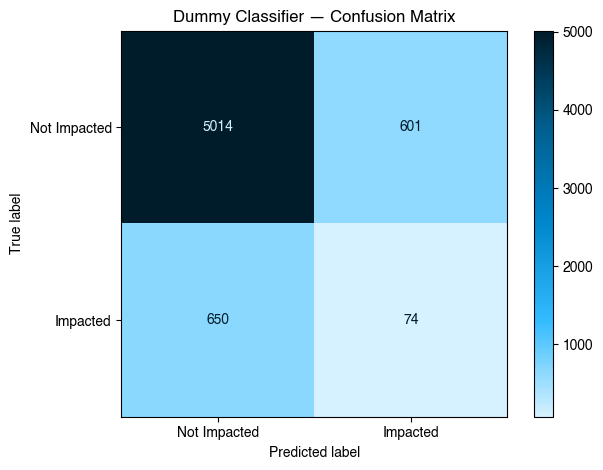

In [65]:
cm_dummy = confusion_matrix(y_test_new, dummy_preds)

disp_dummy = ConfusionMatrixDisplay(confusion_matrix=cm_dummy, display_labels=["Not Impacted", "Impacted"])
disp_dummy.plot(cmap=same_scale_color_map)
plt.title("Dummy Classifier — Confusion Matrix")
plt.tight_layout()
plt.show()

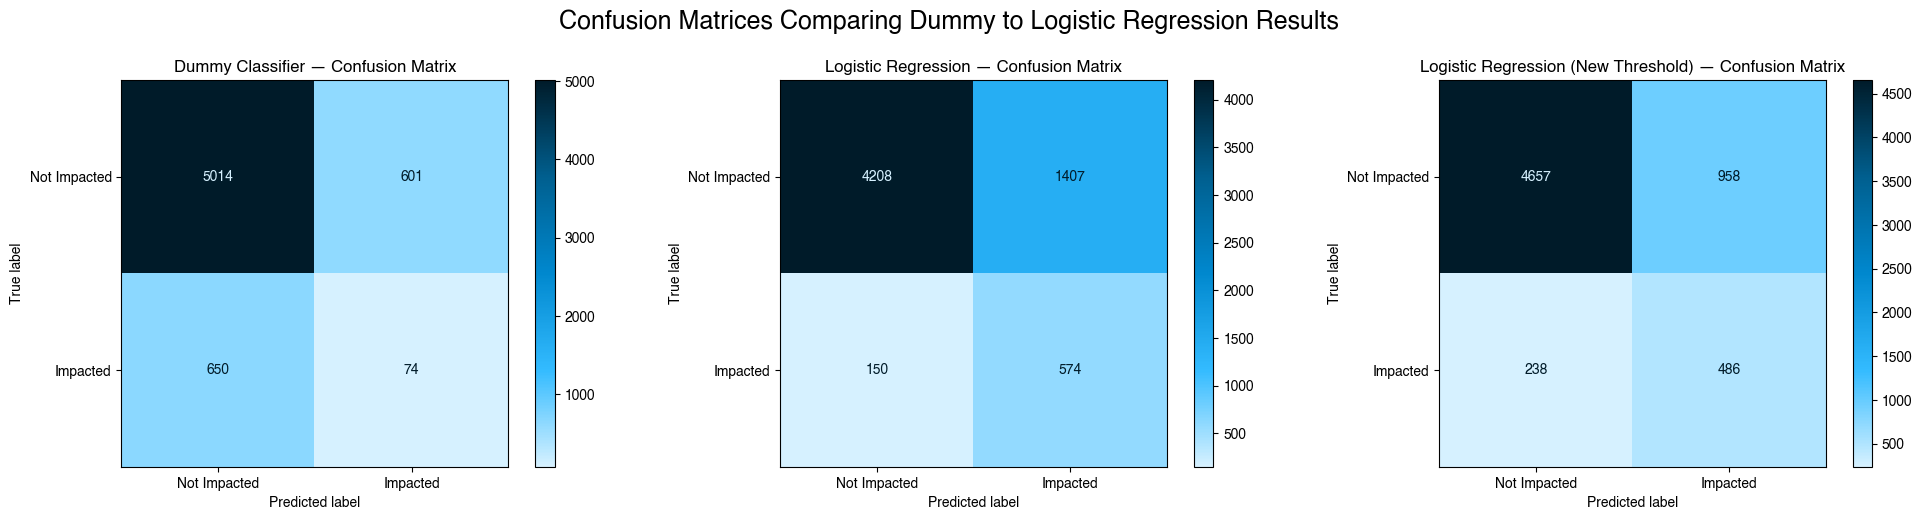

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

cm_dummy = confusion_matrix(y_test_new, dummy_preds)
ConfusionMatrixDisplay(confusion_matrix=cm_dummy, display_labels=["Not Impacted", "Impacted"]).plot(
    cmap=same_scale_color_map, ax=axes[0]
)
axes[0].set_title("Dummy Classifier — Confusion Matrix")

cm = confusion_matrix(y_test_new, predictions)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"]).plot(
    cmap=same_scale_color_map, ax=axes[1]
)
axes[1].set_title("Logistic Regression — Confusion Matrix")

cm = confusion_matrix(y_test_new, predictions_updated)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Impacted", "Impacted"]).plot(
    cmap=same_scale_color_map, ax=axes[2]
)
axes[2].set_title("Logistic Regression (New Threshold) — Confusion Matrix")

fig.suptitle(f'Confusion Matrices Comparing Dummy to Logistic Regression Results', fontsize=18, fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

In [91]:
# Returns "Impacted" / "Not Impacted" for each row
predictions_test_filt = model.predict(X_test_filt)
probabilities_test_filt = model.predict_proba(X_test_filt)[:, 1]  # probability of being impacted


thresholds = [0.3, 0.4, 0.5, 0.6,0.669109, 0.6955, 0.7]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'F1':<10}")
print("-" * 44)
for t in thresholds:
    preds_t = (probabilities_test_filt >= t).astype(int)
    print(f"{t:<12} "
          f"{precision_score(y_test_new_filt, preds_t):<12.3f}"
          f"{recall_score(y_test_new_filt, preds_t):<10.3f}"
          f"{f1_score(y_test_new_filt, preds_t):<10.3f}")

Threshold    Precision    Recall     F1        
--------------------------------------------
0.3          0.255       0.810     0.388     
0.4          0.292       0.752     0.420     
0.5          0.329       0.694     0.447     
0.6          0.367       0.653     0.470     
0.669109     0.407       0.636     0.497     
0.6955       0.416       0.612     0.495     
0.7          0.418       0.612     0.497     


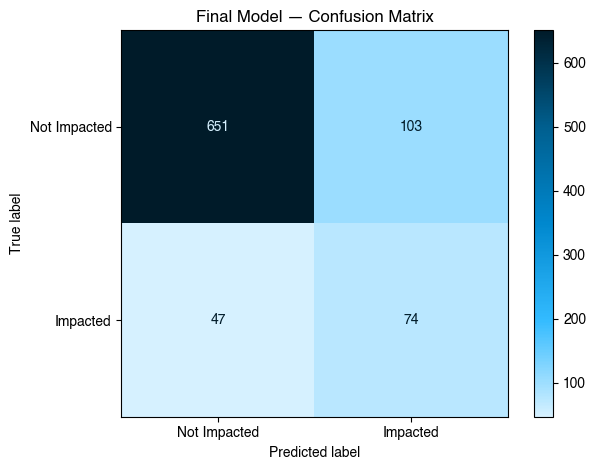

In [94]:
probabilities_test_filt = model.predict_proba(X_test_filt)[:, 1]  # probability of being impacted
final_preds = (probabilities_test_filt >= t).astype(int)

cm_final = confusion_matrix(y_test_new_filt, final_preds)

disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Not Impacted", "Impacted"])
disp_final.plot(cmap=same_scale_color_map)
plt.title("Final Model — Confusion Matrix")
plt.tight_layout()
plt.show()

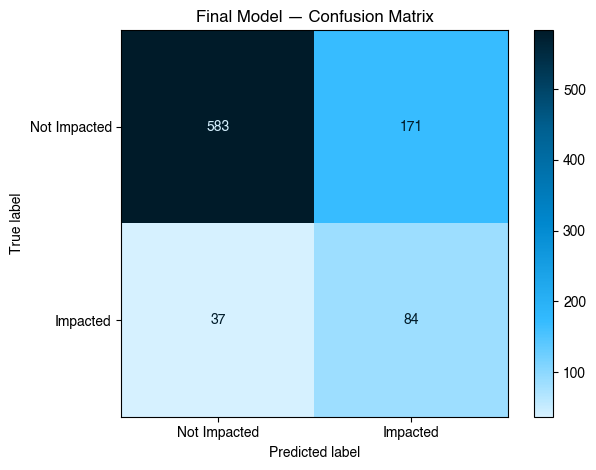

In [95]:
probabilities_test_filt = model.predict_proba(X_test_filt)[:, 1]  # probability of being impacted
final_preds = model.predict(X_test_filt)

cm_final = confusion_matrix(y_test_new_filt, final_preds)

disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Not Impacted", "Impacted"])
disp_final.plot(cmap=same_scale_color_map)
plt.title("Final Model — Confusion Matrix")
plt.tight_layout()
plt.show()

Cleaning up last bit to add to dataframe:

In [96]:
# probabilities = model.predict_proba(X_test)[:, 1]  # probability of being impacted
# predictions_updated = (probabilities >= 0.669109).astype(int)

# keep the set up we had before, it seemed fine 
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced",C=1, l1_ratio=0, solver="liblinear"))
model.fit(X_train, y_train_new)

# make copies of the dataframes to add predictions to
X_train_with_preds_final = X_train.copy()
X_test_with_preds_final = X_test.copy()

#add predictions to the dataframes
X_train_with_preds_final["impacted_prob"] = model.predict_proba(X_train)[:, 1].round(3)
X_train_with_preds_final["impacted_pred"] = (X_train_with_preds_final["impacted_prob"] >= 0.669109).astype(int)


X_test_with_preds_final["impacted_prob"] = model.predict_proba(X_test)[:, 1].round(3)
X_test_with_preds_final["impacted_pred"] = (X_test_with_preds_final["impacted_prob"] >= 0.669109).astype(int)

X_train_with_preds_final.to_csv('../data/cleaned_model_data/complex_filling/x_train_with_predictions_2.csv', index=True)
X_test_with_preds_final.to_csv('../data/cleaned_model_data/complex_filling/x_test_with_predictions_2.csv', index=True)
y_train.to_csv('../data/cleaned_model_data/complex_filling/y_train_2_preds_2.csv', index=True)
y_test.to_csv('../data/cleaned_model_data/complex_filling/y_test_2_preds_2.csv', index=True)

In [121]:
#helper functions 
def find_null_values_in_cols(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0]

def get_na_columns(df):
    nas_finder_new = df.isna().sum()
    return nas_finder_new[nas_finder_new > 0].keys()

# data cleaning functions
def find_bad_storms(df, na_columns):
    # find storms where ALL values are null for any of the cols
    bad_storms = []
    for storm in df['typhoon_name'].unique():
        for col in na_columns:
            if df[df['typhoon_name'] == storm][col].isna().all():
                bad_storms.append(storm)
                break  # no need to check other cols

    bad_storms = list(set(bad_storms))
    return bad_storms

def calculate_storm_medians(df, cols):
    '''
    This function will calculate storm-specific medians for the affected cells and creates a dictionary
    so we can do this for the test set as well.
    '''
    storm_medians = {}
    for storm in df['typhoon_name'].unique():
        storm_medians[storm] = {}
        for col in cols:
            prob_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 1)][col].median()
            not_median = df[(df['typhoon_name'] == storm) & (df['prob_aff'] == 0)][col].median()
            overall_median = df[df['typhoon_name'] == storm][col].median()

            storm_medians[storm][col] = {
                'prob_aff': prob_median,
                'not_affected': not_median,
                'overall_median': overall_median
            }
    return storm_medians

def get_storm_median_for_row(row, storm_medians, col):
    '''
    This function will get the storm-specific medians for a given row, and will check if the s
    '''
    storm_name = row['typhoon_name']
    
    # fallback if storm not seen during training
    if storm_name not in storm_medians:
        return np.nan  # or a global median you pass in
    
    medians = storm_medians[storm_name][col]
    
    if row['prob_aff'] == 1 and not pd.isna(medians['prob_aff']):
        return medians['prob_aff']
    elif row['prob_aff'] == 0 and not pd.isna(medians['not_affected']):
        return medians['not_affected']
    else:
        return medians['overall_median']
    

def drop_correlated_features(X_train,y_train,method='spearman',thresh=0.75):
    
    corr_cols_to_drop = []
    cols_to_skip = []

    for i, col in enumerate(X_train.columns):
        for j in X_train.columns[i+1:]:
            if j in cols_to_skip:
                continue  # skip this column as it's already marked for dropping
            corr = X_train[[col, j]].corr(method=method).iloc[0, 1]
            col_corr = X_train[col].corr(y_train.squeeze(),method=method)
            j_corr = X_train[j].corr(y_train.squeeze(),method=method)
            if abs(corr) > thresh:
                if abs(col_corr) < abs(j_corr):
                    corr_cols_to_drop.append(col)
                    break  # drop col and move to next one
                else:
                    corr_cols_to_drop.append(j)
                    cols_to_skip.append(j)  # skip j in future comparisons
                    continue  # keep col and compare it with next features

    return corr_cols_to_drop

def complex_imputation_of_dataset(X_train, X_test, na_cols):
    median_dict = calculate_storm_medians(X_train, na_cols)

    # now applying these to both the train and test set, so we can impute the nulls with the storm-specific medians
    for col in na_cols:
        # only impute where null — preserve existing values
        null_mask_train = X_train[col].isna()
        null_mask_test = X_test[col].isna()

        X_train.loc[null_mask_train, col] = X_train[null_mask_train].apply(
            lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
        )
        X_test.loc[null_mask_test, col] = X_test[null_mask_test].apply(
            lambda row: get_storm_median_for_row(row, median_dict, col), axis=1
        )

    return X_train, X_test

def clean_and_split_data(df, target_cols, main_target, filling_method='complex', remove_corr_cols=False, thresh=0.75):
    
    # get data
    y = df[main_target]
    X = df.drop(columns=target_cols)

    # drop columns with >95% nulls
    nas_finder = df.isna().sum()
    too_null_cols = [i for i in nas_finder[nas_finder > 0].index if nas_finder.loc[i] / df.shape[0] > 0.95]
    X.drop(columns=too_null_cols, inplace=True)

    # make NA indicator columns
    for i in X.columns[X.isna().any()]:
        X[f'{i}_isna'] = X[i].isna().astype(int)

    # remove storms that have no values for any NA column
    na_cols = get_na_columns(X)
    bad_storms = find_bad_storms(X, na_cols)
    mask = ~X['typhoon_name'].isin(bad_storms)
    X, y = X[mask], y[mask]

    # drop single-value columns
    cols_to_drop = [col for col in X.columns if X[col].nunique() == 1]
    X.drop(columns=cols_to_drop, inplace=True)

    # train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

    na_cols = get_na_columns(X_train)

    if filling_method == 'simple':
        # plain column medians from training set only
        col_medians = X_train[na_cols].median()
        X_train[na_cols] = X_train[na_cols].fillna(col_medians)
        X_test[na_cols]  = X_test[na_cols].fillna(col_medians)

    elif filling_method == 'complex':
        # storm-specific medians, falling back to global median for unseen storms
        global_medians = X_train[na_cols].median().to_dict()
        X_train, X_test = complex_imputation_of_dataset(X_train, X_test, na_cols)
        # apply global median fallback for any remaining nulls (unseen storms in test)
        X_test[na_cols] = X_test[na_cols].fillna(global_medians)

    # drop typhoon_name
    X_train.drop(columns=['typhoon_name'], inplace=True)
    X_test.drop(columns=['typhoon_name'], inplace=True)

    if remove_corr_cols:
        aff_cols = [c for c in X_train.columns if 'aff' in c]
        corr_cols_to_drop = drop_correlated_features(X_train.drop(columns=aff_cols), y_train, 'spearman', thresh)
        X_train.drop(columns=corr_cols_to_drop, inplace=True)
        X_test.drop(columns=corr_cols_to_drop, inplace=True)

    return X_train, X_test, y_train, y_test

def find_correlated_groups(X, method='spearman', thresh=0.75):
    corr = X.corr(method=method).abs()
    G = nx.Graph()
    G.add_nodes_from(X.columns)
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if corr.iloc[i, j] > thresh:
                G.add_edge(corr.columns[i], corr.columns[j])
    groups = [list(c) for c in nx.connected_components(G) if len(c) > 1]
    return groups


def select_representative(group, X_train, y_train, method='spearman', must_include=None):
    # if a must_include col is in this group, return it immediately
    if must_include and must_include in group:
        print(f"Pinned '{must_include}' as representative (must_include)")
        return must_include
    correlations = {col: abs(X_train[col].corr(y_train, method=method)) for col in group}
    return max(correlations, key=correlations.get)


def select_best_features(X_train, y_train, groups, model,
                         method='spearman', large_group_thresh=5, cv=5,
                         must_include=None,max_combos=200):
    must_include = must_include or []
    if isinstance(must_include, str):
        must_include = [must_include]

    all_corr_cols = [col for group in groups for col in group]
    base_cols     = [col for col in X_train.columns if col not in all_corr_cols]

    # ensure any must_include cols that aren't in any group are always in base
    for col in must_include:
        if col not in base_cols and col not in all_corr_cols:
            print(f"Warning: '{col}' not found in X_train columns — skipping")
        if col in all_corr_cols and col not in base_cols:
            pass  # handled per-group below

    selected_from_groups = []
    small_groups = []

    for group in groups:
        pinned = [col for col in must_include if col in group]

        if len(group) > large_group_thresh:
            if pinned:
                # pin the must_include col instead of picking by correlation
                best_col = pinned[0]
                print(f"Large group ({len(group)} features) → pinned: {best_col}")
            else:
                best_col = select_representative(group, X_train, y_train, method)
                print(f"Large group ({len(group)} features) → selected: {best_col}")
            selected_from_groups.append([best_col])
        else:
            if pinned:
                # remove the pinned col from the group so it's not part of
                # the exhaustive search — it'll be added back via fixed_cols
                group = [col for col in group if col not in pinned]
                print(f"Pinning {pinned} from small group, searching remaining {len(group)} cols")
                selected_from_groups.append(pinned)
                if group:
                    small_groups.append(group)
            else:
                small_groups.append(group)

    # exhaustive search over small groups
    if small_groups:
        combos = list(product(*small_groups))
        
        # subsample if too many combinations
        if len(combos) > max_combos:
            import random
            random.seed(42)
            combos = random.sample(combos, max_combos)
            print(f"Subsampled to {max_combos} combinations")
        
        print(f"Searching {len(combos)} combinations from {len(small_groups)} small groups...")
        best_score = -np.inf
        best_combo = None
        fixed_cols = base_cols + [col for group in selected_from_groups for col in group]

        for combo in combos:
            cols = fixed_cols + list(combo)
            scores = cross_val_score(model, X_train[cols], y_train, cv=cv, scoring='r2')
            mean_score = scores.mean()
            if mean_score > best_score:
                best_score = mean_score
                best_combo = combo

        print(f"Best exhaustive combo score: {best_score:.4f}")
        selected_from_groups.append(list(best_combo))

    final_cols = base_cols + [col for group in selected_from_groups for col in group]

    # final safety net — guarantee must_include cols are always present
    for col in must_include:
        if col not in final_cols and col in X_train.columns:
            print(f"Safety net: force-adding '{col}'")
            final_cols.append(col)

    print(f"\nFinal feature count: {len(final_cols)} from original {len(X_train.columns)}")
    return final_cols

def print_consistent_results(model, X_train, y_train, X_test, y_test, cv=5, sample_weight=None):
    '''
    This function takes the model we have, the training and test data, and prints out the 
    cross-validation R² and RMSE (with mean and std), as well as the test set R² and RMSE. 
    This way we can have a consistent way to evaluate different models and compare them.
    '''
    # Cross-validation with R²
    params = {'sample_weight': sample_weight} if sample_weight is not None else {}

    r2_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2',
                                params=params)
    mean_r2 = np.mean(r2_scores)
    std_r2 = np.std(r2_scores)
    
    # Cross-validation with RMSE
    rmse_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error',
                                  params=params)
    mean_rmse = -np.mean(rmse_scores)  # Negate to get positive value
    std_rmse = np.std(rmse_scores)
    
    # Train and predict
    model.fit(X_train, y_train, **params)
    y_pred = model.predict(X_test)
    
    # Test set metrics
    test_r2 = r2_score(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    
    print(f"Cross-validation R²:   {mean_r2:.4f} ± {std_r2:.4f}")
    print(f"Cross-validation RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")
    print(f"Test Set R²:           {test_r2:.4f}")
    print(f"Test Set RMSE:         {test_rmse:.4f}")

def try_out_models_for_col_thresh(X_train,X_test,y_train,y_test,model,col,thresh=0.2):
    train_mask = X_train[col] >= thresh
    test_mask = X_test[col] >= thresh

    X_train = X_train[train_mask]
    y_train = y_train[train_mask]

    X_test = X_test[test_mask]
    y_test = y_test[test_mask]

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    mean_score = scores.mean()
    print(f"mean CV score: {mean_score} with thresh: {thresh}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print(f"R²: {r2_score(y_test, y_pred):.4f}  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    return

def best_lgbm_tester(model,X_train,y_train,X_test,y_test,thresh=0.9):
    corr_cols_to_drop_wo_2 = drop_correlated_features(X_train, y_train_c, 'spearman', 0.9)
    X_train_simp = X_train.drop(columns=corr_cols_to_drop_wo_2)
    X_test_simp = X_test.drop(columns=corr_cols_to_drop_wo_2)

    # best_lgbm_wo_grid.fit(X_train_c_simp_selec_wo,y_train_c)
    print_consistent_results(model, X_train_simp, y_train, 
                            X_test_simp, y_test, cv=5)

    sample_weights = np.where(
        X_train_wo_grid.loc[X_train_simp.index, 'perc_available_upscaled_new'] >= 0.05,
        2.0, 0.5
    )
    print_consistent_results(model, X_train_simp, y_train,
                            X_test_simp, y_test, cv=5,sample_weight=sample_weights)
    
    return



In [146]:
from sklearn.model_selection import train_test_split
# read in complex filled data
df_lc = pd.read_csv('../data/target/model_training_data_final_with_lc.csv')
df_lc = df_lc[df_lc['smod_urban_suburban_perc'] > 0.15]
# df = df[df['smod_urban_suburban_perc'] > 0.20]
X_train_lc, X_test_lc, y_train_lc, y_test_lc = clean_and_split_data(df_lc,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

X_train_lc.drop(columns=['grid_point_id'], inplace=True)
X_test_lc.drop(columns=['grid_point_id'], inplace=True)

# #we need to make our target varaible from a % impact into a binary variable
y_train_lc_new = (y_train_lc > 0).astype(int)
y_test_lc_new = (y_test_lc > 0).astype(int)


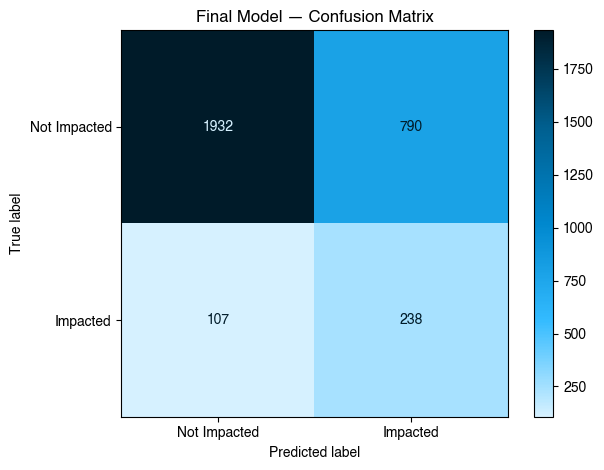

In [147]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced",C=1, l1_ratio=0, solver="liblinear"))
model.fit(X_train_lc, y_train_lc_new)

final_preds = model.predict(X_test_lc)

cm_final = confusion_matrix(y_test_lc_new, final_preds)

disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Not Impacted", "Impacted"])
disp_final.plot(cmap=same_scale_color_map)
plt.title("Final Model — Confusion Matrix")
plt.tight_layout()
plt.show()

0.3466860888565186


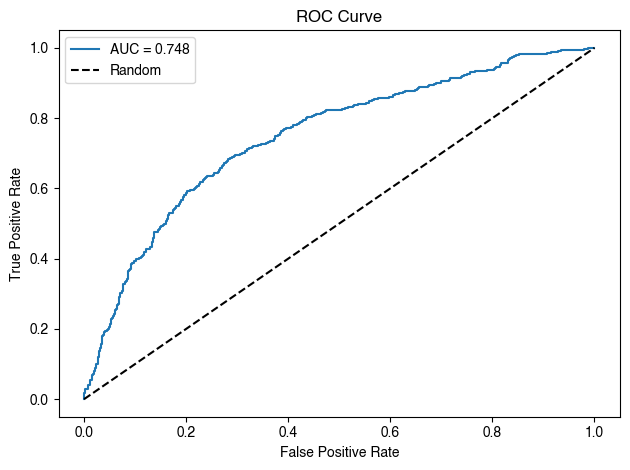

In [148]:
probabilities_lc = model.predict_proba(X_test_lc)[:, 1]  # probability of being impacted

auc = roc_auc_score(y_test_lc_new, probabilities_lc)
fpr, tpr, _ = roc_curve(y_test_lc_new, probabilities_lc)
print(f1_score(y_test_lc_new, final_preds)
      )
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

Original size: 24448, Oversampled size: 29936


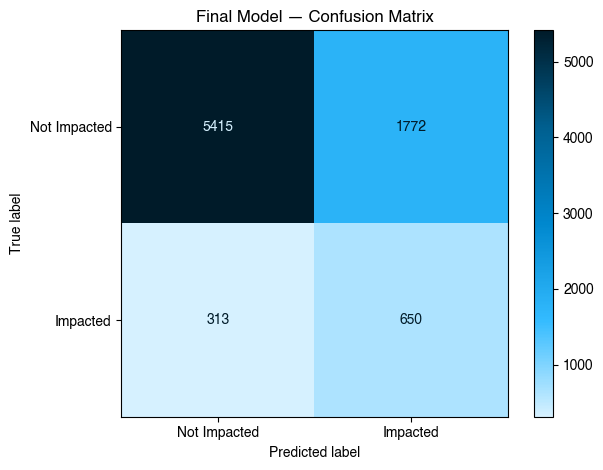

In [156]:
# read in complex filled data
df = pd.read_csv('../data/target/model_training_data_final.csv')
X_train_c, X_test_c, y_train_c, y_test_c = clean_and_split_data(df,['percent_houses_damaged_5years','percent_houses_damaged'],'percent_houses_damaged',filling_method='complex')

X_train_wo_grid = X_train_c.drop(columns=['grid_point_id'])
X_test_wo_grid = X_test_c.drop(columns=['grid_point_id'])

q25 = y_train_c.quantile(0.25)
q75 = y_train_c.quantile(0.75)

tail_mask = (y_train_c < q25) | (y_train_c > q75)
X_tail_wo_grid = X_train_wo_grid[tail_mask]
y_tail = y_train_c[tail_mask]

n_repeats = 2
noise_X = 0.01
noise_y = 0.01 * y_train_c.std()

X_augmented_wo_grid = pd.concat([X_tail_wo_grid + np.random.normal(0, noise_X, X_tail_wo_grid.shape) for _ in range(n_repeats)])
y_augmented = pd.concat([y_tail + np.random.normal(0, noise_y, y_tail.shape) for _ in range(n_repeats)])

X_train_over_wo_grid = pd.concat([X_train_wo_grid, X_augmented_wo_grid]).reset_index(drop=True)
y_train_over = pd.concat([y_train_c, y_augmented]).reset_index(drop=True)

print(f"Original size: {len(X_train_wo_grid)}, Oversampled size: {len(X_train_over_wo_grid)}")

# #we need to make our target varaible from a % impact into a binary variable
y_train_over_new = (y_train_over > 0).astype(int)
y_test_c_new = (y_test_c > 0).astype(int)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,class_weight="balanced",C=1, l1_ratio=0, solver="liblinear"))
model.fit(X_train_over_wo_grid, y_train_over_new)

final_preds = model.predict(X_test_wo_grid)

cm_final = confusion_matrix(y_test_c_new, final_preds)

disp_final = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=["Not Impacted", "Impacted"])
disp_final.plot(cmap=same_scale_color_map)
plt.title("Final Model — Confusion Matrix")
plt.tight_layout()
plt.show()


0.38404726735598227


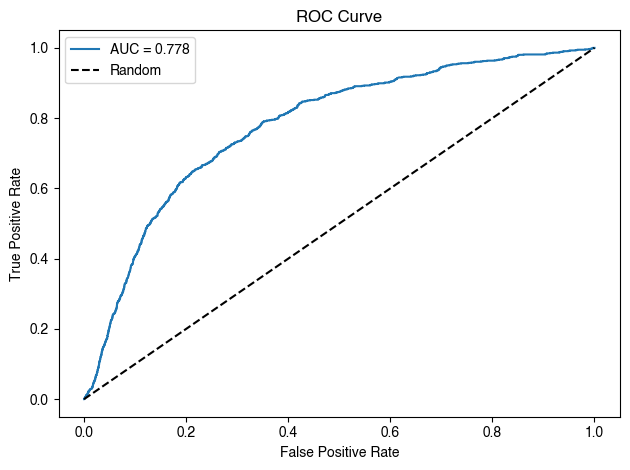

In [157]:
probabilities_c = model.predict_proba(X_test_wo_grid)[:, 1]  # probability of being impacted

auc = roc_auc_score(y_test_c_new, probabilities_c)
fpr, tpr, _ = roc_curve(y_test_c_new, probabilities_c)
print(f1_score(y_test_c_new, final_preds)
      )
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# 0.3861094761624485 0.777 - 2 repeats